<a href="https://colab.research.google.com/github/krlpopiel/SI_lab/blob/develop/lab5_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Input
from keras.callbacks import EarlyStopping

plt.style.use('fivethirtyeight')

with open('/content/completeData.json', 'r') as file:
    raw_json = json.load(file)

ibm_data = raw_json[0]['data']

dataset = pd.DataFrame.from_dict(ibm_data, orient='index')
dataset.index = pd.to_datetime(dataset.index)

dataset = dataset.sort_index(ascending=True)

print(dataset.head())

                open      rsi    macd  stochastic  prev_change  next_change
2024-06-27  161.9486  51.2260  1.0389     73.3109      -0.0009      -0.0016
2024-06-28  161.6931  50.2756  0.9100     59.1046      -0.0016       0.0152
2024-07-01  164.1537  58.3860  0.9950     52.0408       0.0152       0.0080
2024-07-02  165.4692  62.0007  1.1552     47.6949       0.0080       0.0174
2024-07-03  168.3463  68.5240  1.4971     47.6949       0.0174      -0.0120


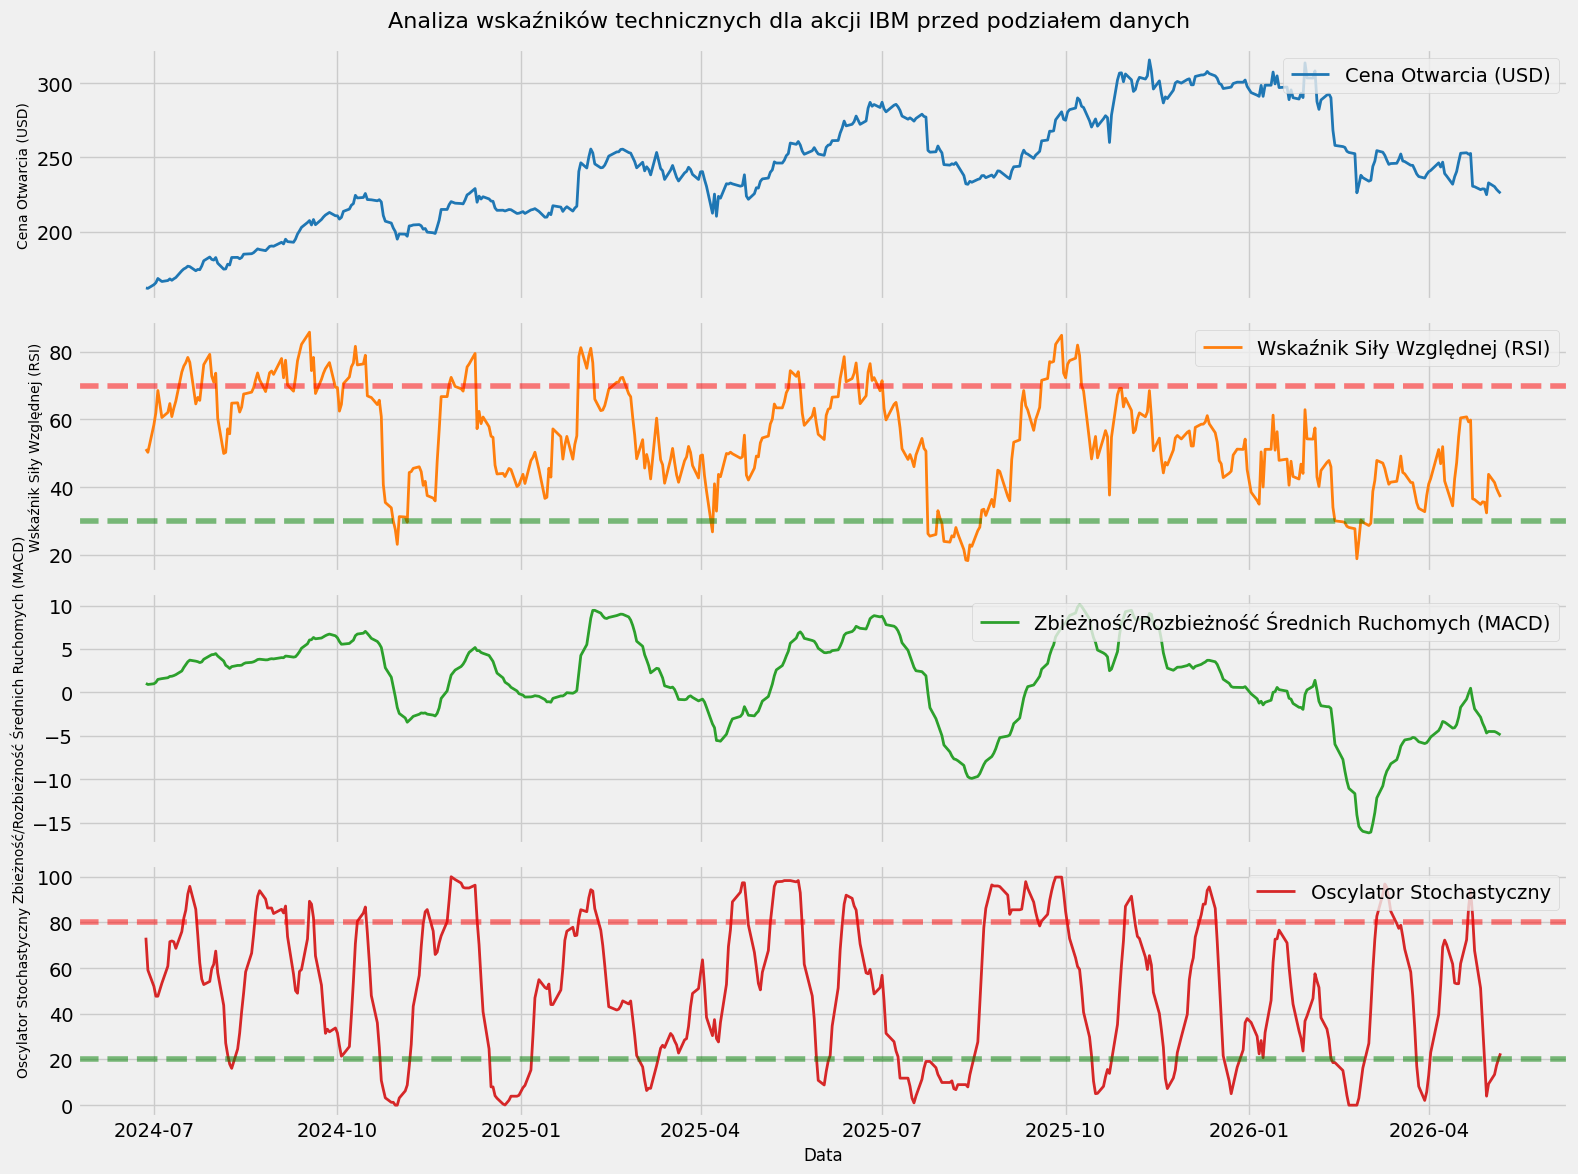

In [8]:
features = ['open', 'rsi', 'macd', 'stochastic']

train_size = int(len(dataset) * 0.8)

training_set = dataset[features].iloc[:train_size].values
test_set = dataset[features].iloc[train_size:].values

sc_features = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc_features.fit_transform(training_set)

sc_target = MinMaxScaler(feature_range=(0, 1))
sc_target.fit(dataset[['open']].iloc[:train_size].values)

tech_labels = {
    'open': 'Cena Otwarcia (USD)',
    'rsi': 'Wskaźnik Siły Względnej (RSI)',
    'macd': 'Zbieżność/Rozbieżność Średnich Ruchomych (MACD)',
    'stochastic': 'Oscylator Stochastyczny'
}

features = ['open', 'rsi', 'macd', 'stochastic']

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 12), sharex=True)

for i, feature in enumerate(features):
    axes[i].plot(dataset.index, dataset[feature], label=tech_labels[feature], color=plt.cm.tab10(i), linewidth=2)

    axes[i].set_ylabel(tech_labels[feature], fontsize=10)
    axes[i].legend(loc='upper right')

    if feature == 'rsi':
        axes[i].axhline(70, color='red', linestyle='--', alpha=0.5)
        axes[i].axhline(30, color='green', linestyle='--', alpha=0.5)
    elif feature == 'stochastic':
        axes[i].axhline(80, color='red', linestyle='--', alpha=0.5)
        axes[i].axhline(20, color='green', linestyle='--', alpha=0.5)

plt.xlabel('Data', fontsize=12)
plt.suptitle('Analiza wskaźników technicznych dla akcji IBM przed podziałem danych', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
time_steps = 30

X_train, y_train = [], []
for i in range(time_steps, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-time_steps:i, :])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

print(f"Nowy kształt X_train: {X_train.shape}")

Nowy kształt X_train: (343, 30, 4)


In [10]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

regressor.add(GRU(units=500, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=500, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=500, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=500))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))
regressor.compile(optimizer='adam', loss='huber')

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0973 - val_loss: 0.0648
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0085 - val_loss: 0.0031
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0041 - val_loss: 0.0142
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0014 - val_loss: 8.9174e-04
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0019 - val_loss: 9.8126e-04
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


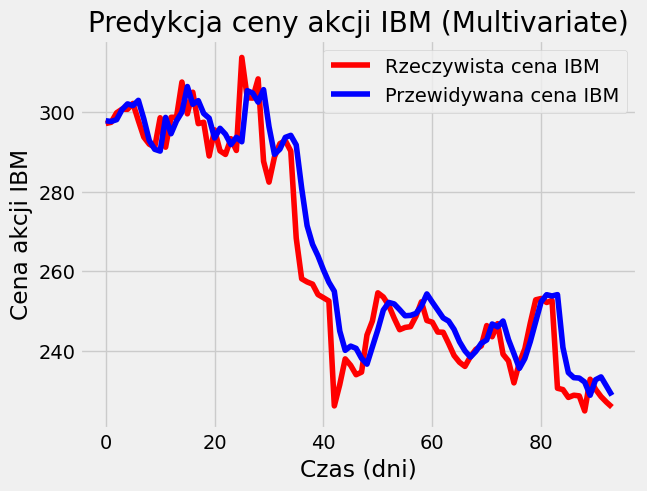

------------------------------
Błąd średniokwadratowy (RMSE): 7.83
------------------------------
Średni błąd bezwzględny (MAE): 5.50
Średni błąd procentowy (MAPE): 2.15%
------------------------------


In [11]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Rzeczywista cena IBM')
    plt.plot(predicted, color='blue', label='Przewidywana cena IBM')
    plt.title('Predykcja ceny akcji IBM (Multivariate)')
    plt.xlabel('Czas (dni)')
    plt.ylabel('Cena akcji IBM')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy (RMSE): {:.2f}".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny (MAE): {:.2f}".format(mae))
    print("Średni błąd procentowy (MAPE): {:.2f}%".format(mape))
    print("-" * 30)

dataset_total = dataset[features]
inputs = dataset_total[len(dataset_total) - len(test_set) - time_steps:].values

inputs = sc_features.transform(inputs)

X_test = []
for i in range(time_steps, len(inputs)):
    X_test.append(inputs[i-time_steps:i, :])

X_test = np.array(X_test)

predicted_scaled = regressor.predict(X_test)

predicted_stock_price = sc_target.inverse_transform(predicted_scaled)

real_stock_price = test_set[:, 0:1]

plot_predictions(real_stock_price, predicted_stock_price)
return_rmse(real_stock_price, predicted_stock_price)
return_mae(real_stock_price, predicted_stock_price)